In [1]:
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="qwen2.5:latest"
)

In [3]:
from pydantic import BaseModel

class ChatState(BaseModel):
    user_input: str
    response: str = ""

In [4]:
def chatbot(state: ChatState):
    reply = llm.invoke(state.user_input)

    return {
        "response": reply.content
    }

## State Graph
    StateGraph is not the graph itself.
    StateGraph is a graph builder that knows what state will flow through your workflow.

In [9]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(ChatState)

builder.add_node("chatbot", chatbot)
builder.set_entry_point("chatbot")
builder.set_finish_point("chatbot")

graph = builder.compile()

result = graph.invoke(
    {
        "user_input": "What is LangGraph?"
    }
)


In [33]:
for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

Hi
================================== Ai Message ==================================

Hello, I am your assistant!


### Build a Basic chatbot with LangGraph
    components ( edges, nodes, state )
    1. GRAPH API "drawing nodes and edges"
    2. FUNCTIONAL API "Suppose your workflow is simple."
    | Approach       | Analogy                         |
    | -------------- | ------------------------------- |
    | Graph API      | Drawing a flowchart             |
    | Functional API | Writing normal Python functions |


    Reducers: "append messages in the state graph"



In [15]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import  add_messages

In [ ]:
# using the llm
from langchain_ollama import ChatOllama

ai = ChatOllama(
    model="qwen2.5:latest"
)

In [20]:
# making the dictionary for the state
class state(TypedDict):
    messages: Annotated[list[dict], add_messages]
    # add_mesages is a reducer it appends, rather than update the whole thing
    user_input: str
    response: str

In [23]:
graphBuilder = StateGraph(state)
graphBuilder.add_node("chatbot", chatbot)
graphBuilder.set_entry_point("chatbot")
graphBuilder.set_finish_point("chatbot")

graphBuilder

In [22]:
ai.invoke("do you love me?")

AIMessage(content="As an AI developed by Alibaba Cloud, I don't have the ability to experience emotions like humans do, including loving someone. However, I'm here to assist you and provide you with the best support and information to the best of my abilities! Is there anything specific you'd like help with or talk about?", additional_kwargs={}, response_metadata={'model': 'qwen2.5:latest', 'created_at': '2026-06-30T17:12:13.1271817Z', 'done': True, 'done_reason': 'stop', 'total_duration': 16072170100, 'load_duration': 13430191400, 'prompt_eval_count': 34, 'prompt_eval_duration': 136242000, 'eval_count': 63, 'eval_duration': 2471471000, 'logprobs': None, 'model_name': 'qwen2.5:latest', 'model_provider': 'ollama'}, id='lc_run--019f1984-1ef2-7203-90f4-be56ccd1b289-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 34, 'output_tokens': 63, 'total_tokens': 97})

In [24]:
result_new = graph.invoke(
    {
        "user_input": "What is life?"
    }
)

print(result_new["response"])

Life can be defined and understood in many ways depending on the perspective from which it is examined—biological, philosophical, or cultural. Here’s an overview:

1. **Biological Perspective**: At its most fundamental level, life refers to organisms that exhibit certain characteristics such as growth, reproduction, responsiveness to stimuli, and metabolism. These living things are distinct from non-living matter because they have the ability to reproduce, maintain homeostasis (a stable internal environment), respond to environmental changes, and grow.

2. **Philosophical Perspective**: Philosophically, life can be seen as a phenomenon or condition that gives purpose, meaning, or value to existence. It may involve concepts such as consciousness, self-awareness, freedom of will, and the pursuit of happiness or well-being.

3. **Cultural Perspective**: Culturally, life is often imbued with specific meanings and values. Different societies and cultures have their own unique understandings

In [25]:
# how to use add.messages to append messages to the state
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list, add_messages]

In [26]:
from langchain_core.messages import AIMessage

def chatbot(state: State):
    return {
        "messages": [
            AIMessage(content="Hello, I am your assistant!")
        ]
    }

In [27]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(State)

builder.add_node("chatbot", chatbot)

builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)

graph = builder.compile()

In [28]:
from langchain_core.messages import HumanMessage

result = graph.invoke(
    {
        "messages": [
            HumanMessage(content="Hi")
        ]
    }
)

print(result)

{'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='2c455310-4a17-478f-b7a7-ce35d1cf49c9'), AIMessage(content='Hello, I am your assistant!', additional_kwargs={}, response_metadata={}, id='92234d4c-965e-43ae-98a3-59cac14ad459', tool_calls=[], invalid_tool_calls=[])]}


In [29]:
{
    "messages": [
        HumanMessage(content="Hi"),
        AIMessage(content="Hello, I am your assistant!")
    ]
}

{'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Hello, I am your assistant!', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]}

##
    Here the chatbot is only the node, not more than that
    

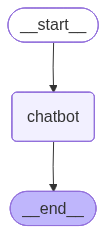

In [32]:
# for visualization of the graphs

from IPython.display import display, Markdown, Image

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    display(Markdown(f"Error displaying graph: {e}"))